# hatchsvg — Quickstart

**Goal:** turn a PNG into a plotter-ready SVG in under 5 minutes.

If anything is unclear, see `explore.ipynb` for the detailed walkthrough,

or `craft.ipynb` for advanced usage.

## Step 1 — Install

```bash

pip install hatchsvg matplotlib

```

Then start Jupyter:

```bash

jupyter lab

```

Open this notebook in Jupyter and run the cells one at a time.

## Step 2 — Load an image

Change `IMAGE_PATH` to point at your own image. PNG, JPG, WebP, BMP, GIF, and TIFF are all supported.

If you don't have an image handy, `../tests/fixtures/test_image.png` (a synthetic 4-color image shipped with the repo) works.

Loaded: 200x200 RGBA


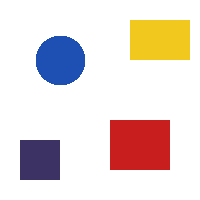

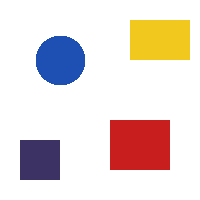

In [1]:
from pathlib import Path
import notebook_helpers as nh

IMAGE_PATH = "../tests/fixtures/test_image.png"  # <-- change this to your own image
img = nh.load_image(IMAGE_PATH)
print(f"Loaded: {img.size[0]}x{img.size[1]} {img.mode}")
nh.display_image(img)

## Step 3 — Quantize (fast, ~300ms)

The quantize step finds the dominant colors in the image.

Try changing `MAX_PALETTE` to 4, 8, 16, or 24 and re-running this cell to see the effect.

Exact-color mode: 5 colors.


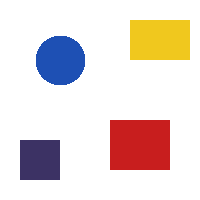

**Quantized** — 5 colors:

| # | Color | Hex | Pixels | % of visible |
|---|-------|-----|--------|--------------|
| 0 | blue | `#1E50B4` | 1,941 | 4.9% |
| 1 | blue | `#3C3264` | 1,600 | 4.0% |
| 2 | red | `#C81E1E` | 3,000 | 7.5% |
| 3 | yellow | `#F0C81E` | 2,400 | 6.0% |
| 4 | white | `#FFFFFF` | 31,059 | 77.6% |

In [2]:
MAX_PALETTE = 12  # try 4 (cartoon), 8 (portrait), 16+ (photo)
quant = nh.quantize_image(img, max_palette=MAX_PALETTE)
preview = nh.render_quantized_preview(img, quant)
nh.display_image(preview)
from IPython.display import Markdown, display

display(Markdown(nh.format_quantize_report(quant)))

## Step 4 — Render the SVG (slow)

This is the slow step — it generates the actual hatch paths. For a 1500×2000 image, expect 5-30 seconds.



We start with the `fast` preset to validate the workflow quickly (3-5s).

When you're happy with the color choices, re-run this cell with `preset='portrait'`

for the dense, high-quality final version (30-60s).



**Don't change parameters randomly and re-run** — this is the expensive step.

Use Step 3 first to validate color choices.

In [3]:
result = nh.render_svg(
    img,
    preset="fast",  # change to 'portrait' for the final version
    palette=None,  # set to a palette dict to use physical markers
    max_palette=MAX_PALETTE,
    continuous_paths=True,  # chains rows to reduce pen lifts
    arc_radius=5.0,  # smooth U-turns; 0 disables
)
from IPython.display import Markdown, display

display(Markdown(nh.format_render_report(result)))

Loading image: /tmp/hatchsvg_notebook_input.png

Quantizing: Found 5 unique colors > max_palette=4.


Colors used: 4

Background detected as index 0, RGB=(255, 255, 255)


Skip BG idx 0

idx 1: dark_red (#C81E1E) RGB=(200, 30, 30), L=66.1, white=False, pixels=3000, ls=10
idx 2: light_yellow (#F0C81E) RGB=(240, 200, 30), L=196.2, white=False, pixels=2400, ls=11
idx 3: mid_blue (#1E50B4) RGB=(30, 80, 180), L=76.6, white=False, pixels=1941, ls=8


Saved 3 color layers to /tmp/hatchsvg_notebook_output.svg (separate_outline=False, naming_mode=inkscape)

**Rendered**

- Layers: 3
- Total segments: 18
- Pen lifts (optimized): 3
- Pen lifts (legacy): 18
- Pen-lift reduction: 83.3%
- Output: `/tmp/hatchsvg_notebook_output.svg`

## Step 5 — Preview and download

Display the SVG inline (works in Jupyter, not on GitHub) and save a copy to disk.

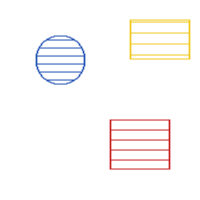

Saved: /home/jcharles/Projects/python/png2svg/notebooks/my_drawing.svg (4,184 bytes)


In [4]:
# Display inline
nh.display_svg(result["svg_path"])

# Save a copy with a friendlier name
import shutil
from pathlib import Path

out_path = Path("my_drawing.svg")
shutil.copy(result["svg_path"], out_path)
print(f"Saved: {out_path.absolute()} ({out_path.stat().st_size:,} bytes)")

## Next steps

- Open `explore.ipynb` to understand what each step does (and why)

- Open `craft.ipynb` for advanced usage: custom marker palettes, batch processing, reproducibility

- Or use the CLI directly: `hatchsvg tests/fixtures/test_image.png out.svg --preset portrait`